In [2]:
%load_ext autoreload
%autoreload 2

import ezy_seq as ezy
#import ezy_seq.load 
import scanpy as sc
import pandas as pd
import os
from pathlib import Path  # For file path operations
import matplotlib.pyplot as plt
import napari
import glob
import numpy as np
import pathlib
from matplotlib.path import Path as MPath  # For polygon operations (matplotlib Path)
import random
random.seed(42)

c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [20]:
#adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\E4FAD\H5ADs\working.h5ad")
adata_full=sc.read_h5ad(r"C:\Users\woods\OneDrive - University of Missouri\General - Lin Brain Lab - Ogrp\Carter Woods\CosMx_Processing\Manuscript\fully_updated.h5ad")


In [4]:
sc.pp.scale(
    adata_full,
    zero_center=True,       # Subtract the mean from each gene (result has 0 mean)
    max_value=10,           # Clip values exceeding this standard deviation (prevents outliers from dominating)
    copy=False,             # Modify the AnnData object in place
    layer=None,             # Scale a specific layer instead of .X
    obsm=None               # Scale a specific multi-dimensional observation annotation
)

c:\Users\woods\miniconda3\envs\new_env\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
sub=adata_full[adata_full.obs['ct_simple'].isin(['Astrocytes','Cholinergic.neurons','Microglia','Inhibitory.neurons','Mature.oligodendrocytes','Excitatory.neurons'])]


In [6]:
sub=adata_full

In [7]:
sub.obs['ct_simple'].unique()

['Endothelial.cells', 'Committed.oligodendrocytes', 'Interneurons', 'Purkinje.cells', 'Astrocytes.Bergmann.glia', ..., 'CCK.interneurons', 'Serotonergic.neurons', 'Granule.neurons', 'Epithelial.cells', 'Cajal.Retzius.cells']
Length: 33
Categories (33, object): ['Astrocytes', 'Astrocytes.Bergmann.glia', 'CCK.interneurons', 'Cajal.Retzius.cells', ..., 'T.cell', 'Tanycytes', 'Vascular.leptomeningeal.cells', 'Vascular.smooth.muscle.cells']

In [8]:
sub.obs['FMT'].unique()

['Stroke_FMT', 'Healthy_FMT', 'Cntrl']
Categories (3, object): ['Cntrl', 'Healthy_FMT', 'Stroke_FMT']

In [21]:

#sub=adata_full[adata_full.obs['ct_simple'].isin(['Cholinergic.neurons', 'Excitatory.neurons', 'Inhibitory.neurons', 'Mature.oligodendrocytes', 'Microglia', 'Astrocytes'])]
sub=adata_full[adata_full.obs['FMT'].isin(['Healthy_FMT','Stroke_FMT'])]
sub=sub[sub.obs['napari_regioin']!='Olfactory']


KeyError: 'napari_regioin'

--- Step 1: PCA (Principal Component Analysis) ---
--- Step 1: PCA ---


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


--- Step 2: Neighbors ---


c:\Users\woods\miniconda3\envs\new_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Step 3: UMAP ---
--- Visualization ---


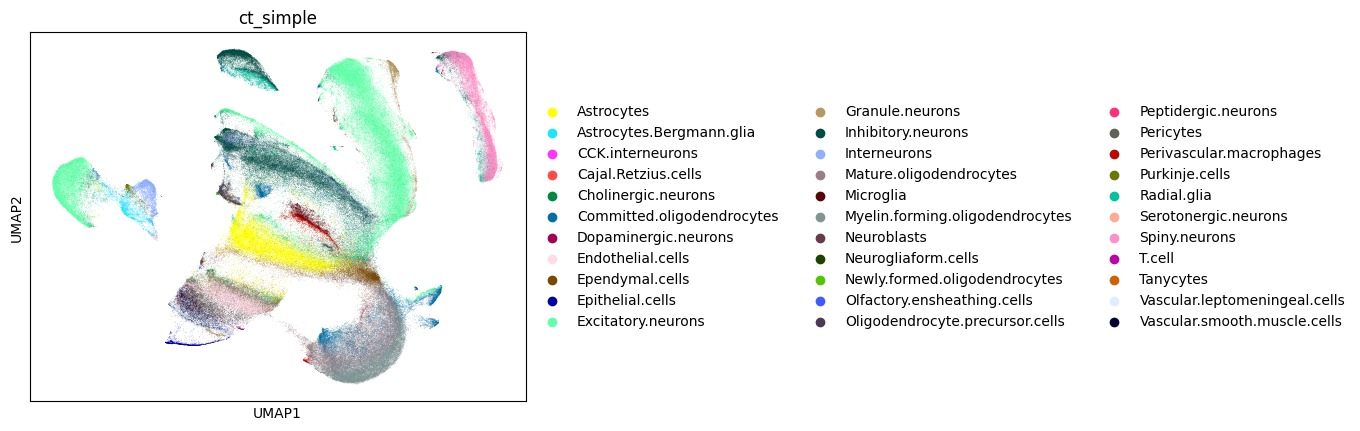

In [12]:
import scanpy as sc

# Assuming 'adata' is your filtered and logarithmized AnnData object
# Note: It is highly recommended to select highly variable genes before running PCA.

print('--- Step 1: PCA (Principal Component Analysis) ---')
# Parameters are based on sc.tl.pca (which uses sklearn or arpack)

print('--- Step 1: PCA ---')
sc.tl.pca(
    sub, 
    n_comps=15,                  # DECREASED: 15 to 20 is plenty for 1000 genes
    zero_center=True, 
    svd_solver='arpack', 
    random_state=0, 
    use_highly_variable=False,   # EXPLICIT: Set to False IF you haven't run the HVG function.
    dtype='float32', 
    copy=False
)

print('--- Step 2: Neighbors ---')
sc.pp.neighbors(
    sub, 
    n_neighbors=10,              # Keep this low for tight clusters
    n_pcs=15,                    # MATCH this to your new n_comps
    knn=True, 
    random_state=0, 
    method='umap', 
    metric='cosine',             # Keep cosine!
    copy=False 
)

print('--- Step 3: UMAP ---')
# This computes the embedding itself
sc.tl.umap(
    sub, 
    min_dist=0.05,                # Effective minimum distance between embedded points
    spread=1.5,                  # Effective scale of embedded points
    n_components=2,              # The dimension of the space to embed into
    maxiter=None,                # Max number of iterations for optimization (None = auto)
    alpha=1.0,                   # Initial learning rate for the optimization
    gamma=1.0,                   # Weighting of the negative samples
    negative_sample_rate=5,      # Number of negative samples to select per positive sample
    init_pos='spectral',         # How to initialize the low dimensional embedding
    random_state=0,              # Seed for the random number generator
    a=None,                      # Parameter 'a' of the UMAP curve (None = inferred)
    b=None,                      # Parameter 'b' of the UMAP curve (None = inferred)
    copy=False,                  # Return a copy or modify in place
    method='umap',               # UMAP implementation ('umap' or 'rapids')
    neighbors_key=None           # Key in adata.uns where neighbor info is stored
)

print('--- Visualization ---')
sc.pl.umap(sub,color='ct_simple')

In [18]:
import re
import pandas as pd

_NORM = {
    "fiber tracts":                    "Fiber tract",
    "fiber tract - lateral ventricle": "Fiber tract",
    "fiber tract":                     "Fiber tract",
    "denate gyrus":                    "Dentate Gyrus",
    "medulla":                         "Medulla",
}

_PREFIX_MAP = {
    "midbrain": "Midbrain",
}

def clean_one(region):
    if pd.isna(region):
        return pd.NA
    r = str(region).strip()
    if re.fullmatch(r"[\d,\s]+", r):
        return pd.NA
    if "," in r:
        r = r.split(",")[0].strip()
    for prefix, canonical in _PREFIX_MAP.items():
        if r.lower().startswith(prefix):
            return canonical
    canonical = _NORM.get(r.lower())
    if canonical:
        return canonical
    return r

sub.obs['quint_region_clean'] = sub.obs['quint_region'].map(clean_one)
sub = sub[sub.obs['quint_region_clean'].notna()].copy()

In [16]:
list(sub.obs['quint_region'].unique())

['Cerebellar cortex',
 'Fiber tract',
 'Cerebellar nucleus',
 'Fiber tract - lateral ventricle',
 'medulla',
 'Pons',
 'Midbrain misc',
 'Midbrain, sensory related',
 'Hypothalamus',
 'Cerebral Nuclei, Pallidum',
 'Cerebral Nuclei, Striatum',
 '0,0,0',
 'Midbrain, motor related',
 'Geniculate group, dorsal thalamus',
 'Ventral group dorsal thalamus',
 'Thalamus, polymodal association cortex related',
 'Olfactory',
 'Fiber Tracts',
 'Retrohippocampal region',
 'Cortex, Orbital',
 'Cortex, Retrosplenial area',
 '17,112,103',
 'Hippocampus',
 'Subiculum',
 'Denate Gyrus',
 'Cortex, Visual areas',
 'Cortex, Somatamotor areas',
 'Cortex, Frontal pole',
 'Cortex, Somatasensory areas',
 'Cortex, Posterior parietal association areas',
 '18,114,104',
 '12,79,72',
 '7,46,42',
 '16,102,93',
 '1,10,9',
 'Cortex,Orbital,Angular insular area',
 'Cerebral Nuclei, Striatum, Stiatum-like amygdalar nuclei',
 'Cortex, Amygdalar area',
 'Cortical subplate',
 'Retrohippocampal region, Entorhinal area',
 'C

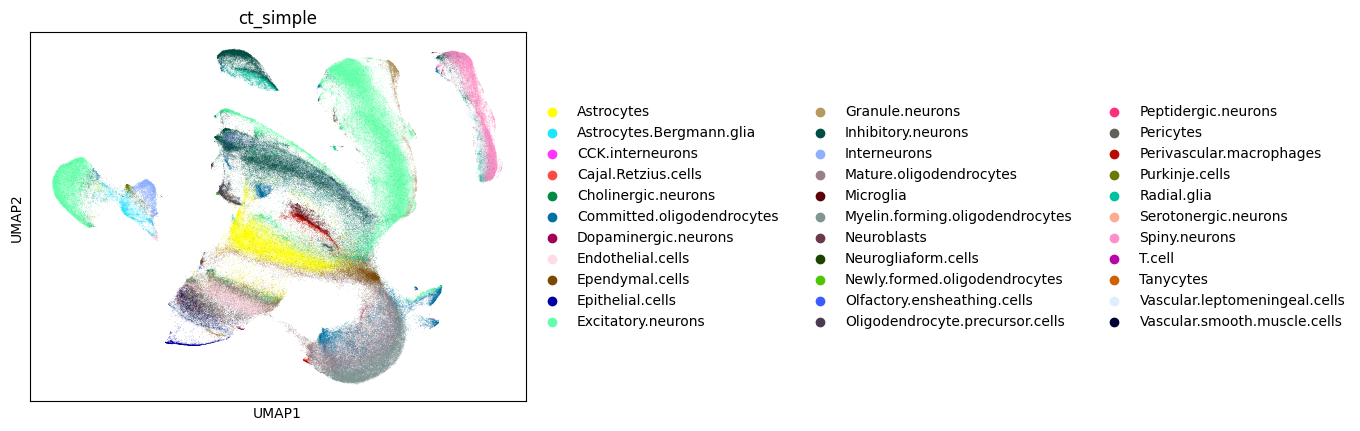

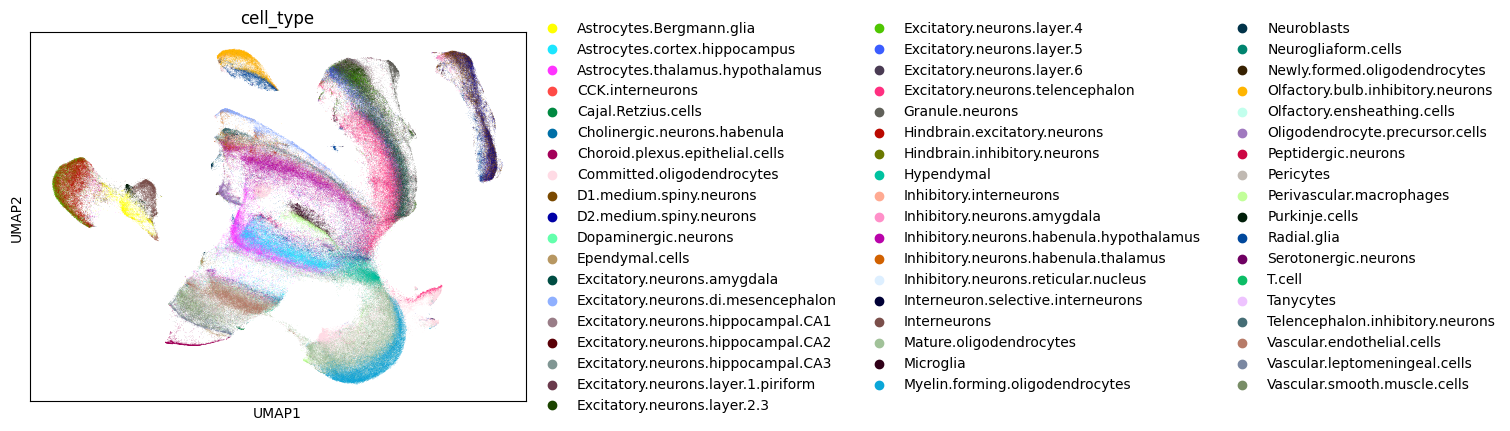

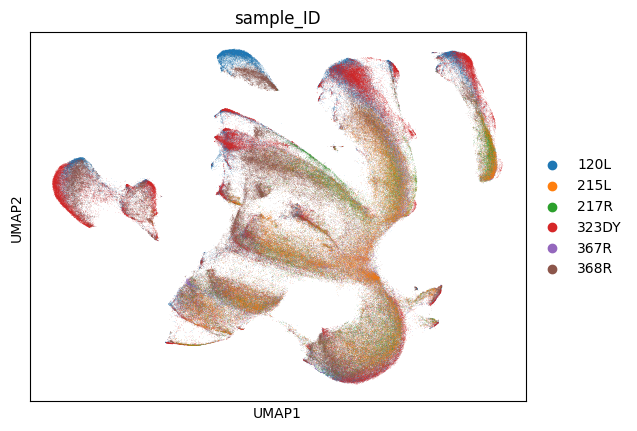

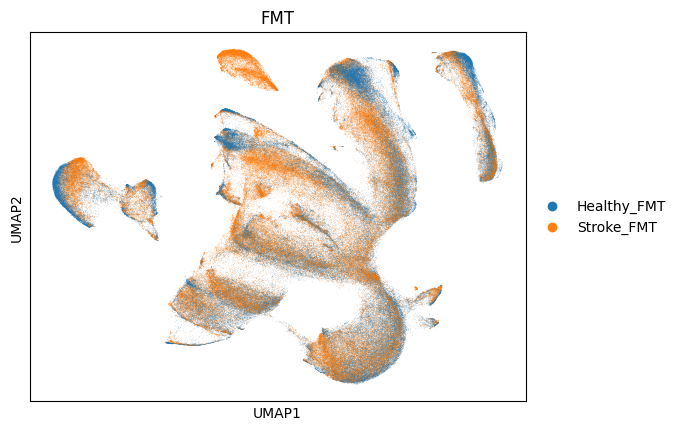

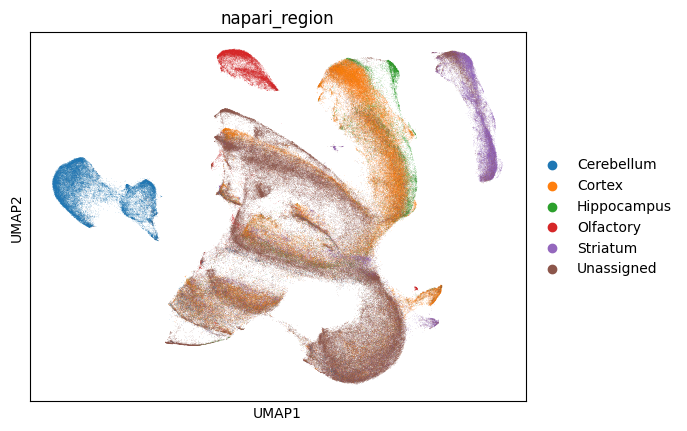

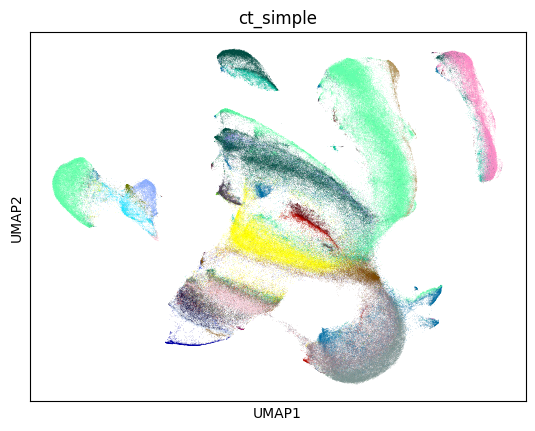

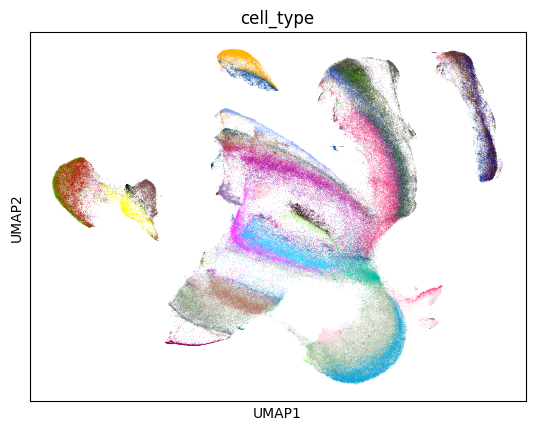

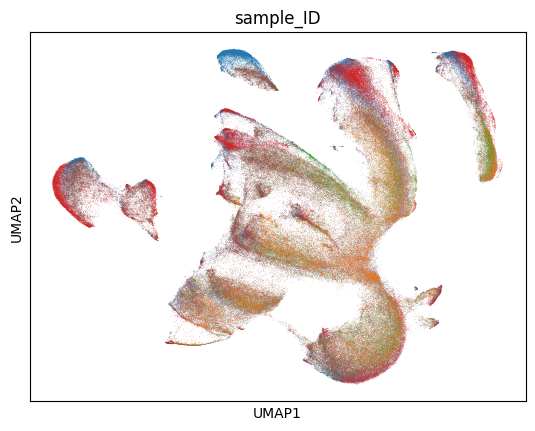

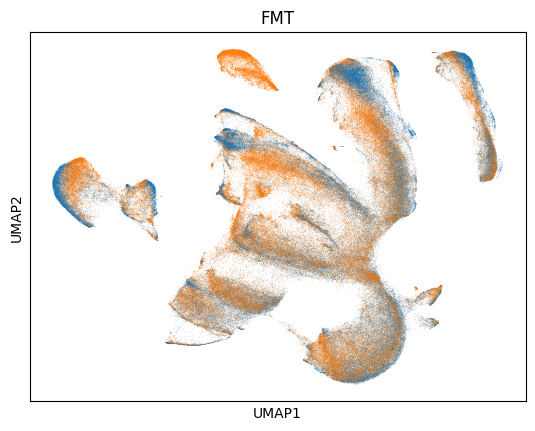

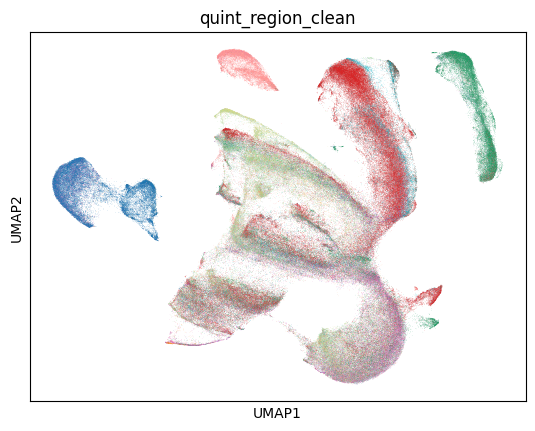

In [19]:
sc.pl.umap(sub,color='ct_simple',title='ct_simple')
sc.pl.umap(sub,color='cell_type',title='cell_type')
sc.pl.umap(sub,color='sample_ID',title='sample_ID')
sc.pl.umap(sub,color='FMT',title='FMT')
sc.pl.umap(sub,color='napari_region',title='napari_region')

sc.pl.umap(sub,color='ct_simple',title='ct_simple',legend_loc=None)
sc.pl.umap(sub,color='cell_type',title='cell_type',legend_loc=None)
sc.pl.umap(sub,color='sample_ID',title='sample_ID',legend_loc=None)
sc.pl.umap(sub,color='FMT',title='FMT',legend_loc=None)
sc.pl.umap(sub,color='quint_region_clean',title='quint_region_clean',legend_loc=None)

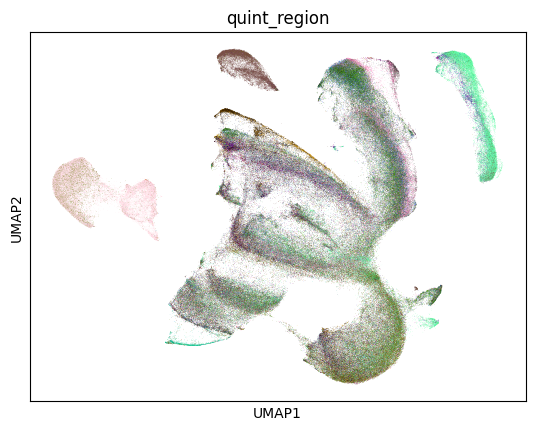

In [15]:
sc.pl.umap(sub,color='quint_region',title='quint_region',legend_loc=None)